In [2]:
import pandas as pd
import json
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns


In [17]:
books_df = pd.read_csv('./clean_merge/books.csv', low_memory=False)
ratings_df = pd.read_csv('./clean_merge/ratings.csv',low_memory=False)
books_genres_df = pd.read_csv('./clean_merge/book_genres.csv',low_memory=False)
users_df = pd.read_csv('./clean_merge/users.csv',low_memory=False)

In [18]:
books_df

,id,title,crawl_source,ISBN_10,description,image_url,author,language,publish_date,num_pages
0,9780578406053,The Beauty Of The Mass: Exploring The Central ...,hardcover,0578406055,An in-depth dive through every aspect of the H...,https://assets.hardcover.app/edition/31306658/...,Charles S. Johnston,English,2018-11-12,0.0
1,9781438407166,"Collaborative Construction of Pretend, The",hardcover,1438407165,The Collaborative Construction of Pretend expl...,https://assets.hardcover.app/external_data/601...,Carollee Howes,English,1992-01-01,172.0
2,9780751503890,The Physician,goodreads,0751503894,"In the 11th century, Rob Cole left poor, disea...",https://images-na.ssl-images-amazon.com/images...,Noah Gordon,English,2001-07-01,714.0
3,9783834915528,Operationalisierung einer Nachhaltigkeitsstrat...,hardcover,3834915521,Alexandro Kleine entwickelt ein Operationalisi...,https://assets.hardcover.app/external_data/601...,Alexandro Kleine,English,2009-02-26,232.0
4,9782226109552,Lorsque j'étais une œuvre d'art,hardcover,2226109552,Lorsque j'étais une œuvre d'art est un livre s...,https://assets.hardcover.app/external_data/599...,Éric-Emmanuel Schmitt,English,2002-01-01,294.0
...,...,...,...,...,...,...,...,...,...,...
284918,9780316365819,"The Witches: Salem, 1692",hardcover,0316200603,The Pulitzer Prize-winning author of Cleopatra...,https://assets.hardcover.app/external_data/266...,Stacy Schiff,English,2015-01-01,498.0
284919,9788741859552,Det brændte barn,hardcover,NaN,NaN,https://assets.hardcover.app/external_data/603...,Ursula K. Le Guin,English,1990-06-20,238.0
284920,9781508706250,The Deal,hardcover,1508706255,Hannah Wells is a student at Briar University ...,https://assets.hardcover.app/external_data/599...,Elle Kennedy,English,2015-01-01,376.0
284921,9780070045491,"Probability, Statistics, and Decisions for Civ...",goodreads,0070045496,"Book by Benjamin, J R, Cornell, C A",https://images-na.ssl-images-amazon.com/images...,Jack R. Benjamin,English,1970-01-01,640.0


In [19]:
books_genres_df

,isbn13,genre_name
0,9780761823889,Anthropology
1,9782897771034,Fiction
2,9789021439587,Authors
3,9780553274813,Humor
4,9781619638617,Science Fiction
...,...,...
682217,9780060512149,Fiction
682218,9780892552900,College
682219,9780446571746,Science fiction
682220,9781591797944,Mind & Spirit


In [20]:
users_df

,full_name,account_source,userid_source,new_user_id
0,Douglas,goodreads,26,1
1,Courtney,goodreads,284,2
2,kaitlin,goodreads,675,3
3,Scott,goodreads,713,4
4,erin,goodreads,819,5
...,...,...,...,...
40309,Lily Ostler,hardcover,23475,40310
40310,Keelin,hardcover,23477,40311
40311,ubyhb,hardcover,23478,40312
40312,Ainsley,hardcover,23481,40313


In [38]:
# Display the unique genre names
unique_genres = books_genres_df['genre_name'].str.lower().unique()

# Print the number of unique genres and their values
print("Unique genres:")
unique_genres

Unique genres:


array(['anthropology', 'fiction', 'authors', ...,
       'animated television programs', 'termites', 'creative teaching'],
      dtype=object)

In [39]:
num_books = books_df.shape[0]
num_ratings = ratings_df.shape[0]
unique_users = users_df.shape[0]

ratings_per_user = num_ratings / unique_users if unique_users else None
ratings_per_book = num_ratings / num_books

# Print statistics
print(f"Number of books: {num_books}")
print(f"Number of ratings: {num_ratings}")
print(f"Number of unique users: {unique_users}")
print(f"Number of unique genres: {len(unique_genres)}")
print(f"Average number of ratings per user: {ratings_per_user:.2f}" if ratings_per_user else "User data not available")
print(f"Average number of ratings per book: {ratings_per_book:.2f}")

Number of books: 284923
Number of ratings: 1409156
Number of unique users: 40314
Number of unique genres: 7543
Average number of ratings per user: 34.95
Average number of ratings per book: 4.95


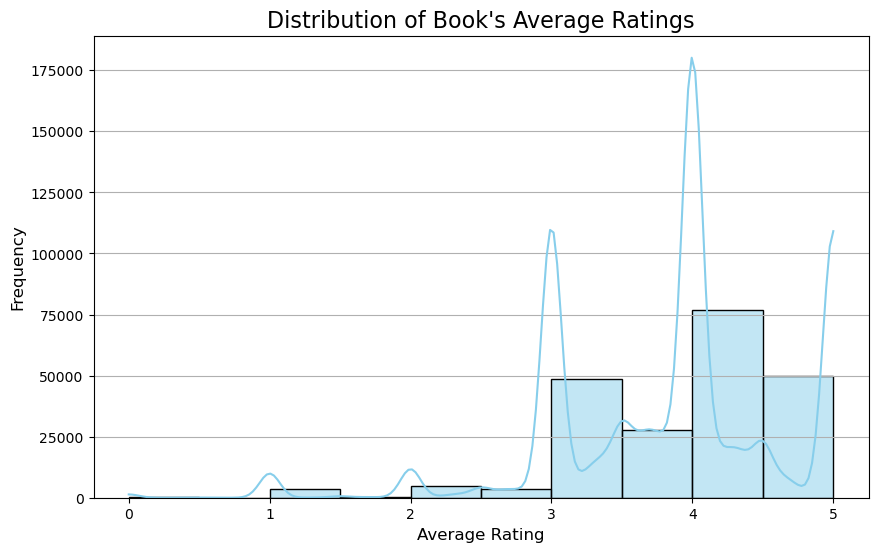

In [25]:
# preprocess the ratings to calculate the average rating per book
average_ratings = ratings_df.groupby("isbn13")["rating_score"].mean().reset_index()
average_ratings.columns = ["isbn13", "avg_rating"]

# Distribution of book's average rating by range
plt.figure(figsize=(10, 6))
sns.histplot(average_ratings["avg_rating"], bins=10, kde=True, color='skyblue')
plt.title("Distribution of Book's Average Ratings", fontsize=16)
plt.xlabel("Average Rating", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(axis='y')
plt.show()

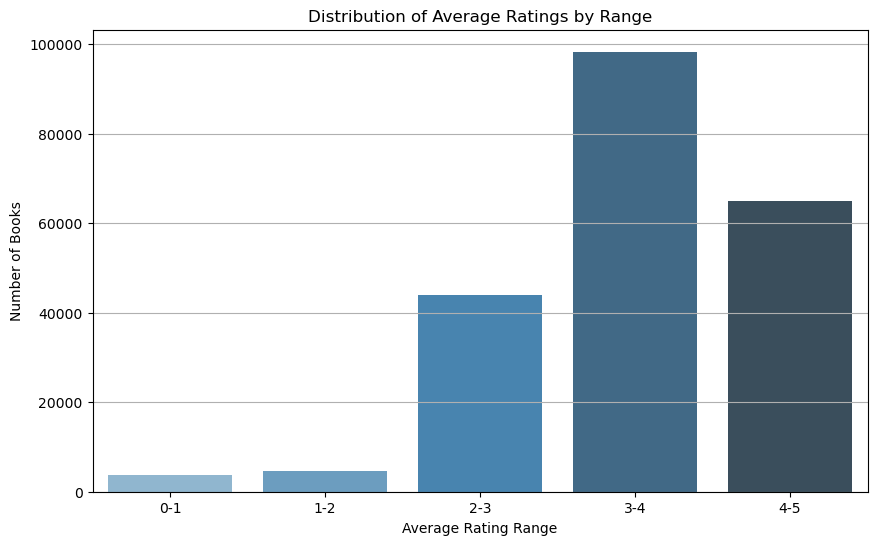

In [33]:
# Create bins for average rating ranges
rating_bins = pd.cut(average_ratings['avg_rating'], bins=[0, 1, 2, 3, 4, 5], labels=['0-1', '1-2', '2-3', '3-4', '4-5'])

# Count the number of books in each bin
rating_range_counts = rating_bins.value_counts().sort_index()

# Plot the grouped data as a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=rating_range_counts.index, y=rating_range_counts.values, palette='Blues_d')
plt.title('Distribution of Average Ratings by Range')
plt.xlabel('Average Rating Range')
plt.ylabel('Number of Books')
plt.grid(axis='y')
plt.show()

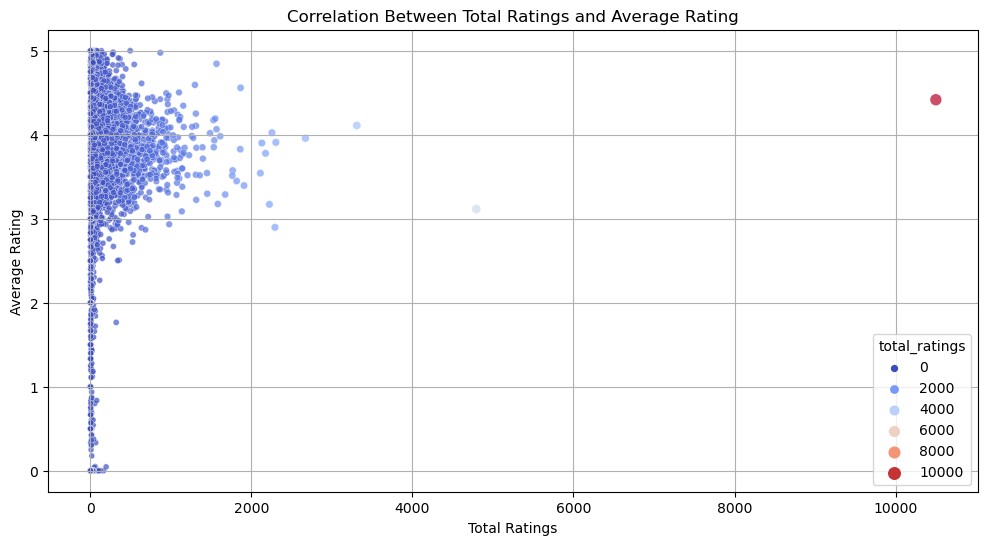

In [34]:
# Correlation of user's total ratings vs average rating
user_ratings_count = ratings_df.groupby("new_user_id")["isbn13"].count().reset_index()
user_ratings_count.columns = ["new_user_id", "total_ratings"]

# merge user total ratings with ratings to get user-wise average rating
user_avg_ratings = ratings_df.groupby("new_user_id")["rating_score"].mean().reset_index()
user_avg_ratings.columns = ["new_user_id", "avg_rating"]

data = pd.merge(user_ratings_count, user_avg_ratings, on="new_user_id")

plt.figure(figsize=(12, 6))
sns.scatterplot(data=data, x="total_ratings", y="avg_rating", alpha=0.7, hue='total_ratings', size='total_ratings', palette='coolwarm')
plt.title("Correlation Between Total Ratings and Average Rating")
plt.xlabel("Total Ratings")
plt.ylabel("Average Rating")
plt.grid(True)
plt.show()
